# Backtesting the Markowitz-Optimized Portfolio

Simulating how the Max Sharpe Ratio portfolio (identified in Notebook 01) would have
actually performed if invested in and held over time, compared to relevant benchmarks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the same price data used throughout this project
df = pd.read_csv('../data/raw_prices.csv', header=[0, 1], index_col=0, parse_dates=True)
close_prices = df['Close']
close_prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2019-01-02,37.469204,76.956497,52.270508,94.193138,20.674667
2019-01-03,33.736996,75.014000,50.822842,90.727959,20.024000
2019-01-04,35.177208,78.769501,53.429718,94.947639,21.179333
2019-01-07,35.098907,81.475502,53.323177,95.068748,22.330667
2019-01-08,35.768009,82.829002,53.791519,95.758072,22.356667


## Define Optimization Period vs. Backtest Period

To properly test the Markowitz strategy, we split the data in time: portfolio weights
are calculated using only the "optimization period" (2019–2022), then applied unchanged
to the separate, later "backtest period" (2023–2025) to see how they would have actually
performed on data not used to design them.

In [2]:
# Define the split date
split_date = '2023-01-01'

# Optimization period: used to CALCULATE the portfolio weights
optimization_prices = close_prices[close_prices.index < split_date]

# Backtest period: used to TEST those weights on unseen data
backtest_prices = close_prices[close_prices.index >= split_date]

print(f"Optimization period: {optimization_prices.index.min()} to {optimization_prices.index.max()} ({len(optimization_prices)} days)")
print(f"Backtest period: {backtest_prices.index.min()} to {backtest_prices.index.max()} ({len(backtest_prices)} days)")

Optimization period: 2019-01-02 00:00:00 to 2022-12-30 00:00:00 (1008 days)
Backtest period: 2023-01-03 00:00:00 to 2024-12-31 00:00:00 (502 days)


## Calculate Max Sharpe Weights (Optimization Period Only)

Repeating the Markowitz simulation from Notebook 01, restricted to the optimization
period (2019–2022) only, so the resulting weights can be honestly tested on the
separate backtest period.

In [3]:
# Define the split date
split_date = '2023-01-01'

# Optimization period: used to CALCULATE the portfolio weights
optimization_prices = close_prices[close_prices.index < split_date]

# Backtest period: used to TEST those weights on unseen data
backtest_prices = close_prices[close_prices.index >= split_date]

print(f"Optimization period: {optimization_prices.index.min()} to {optimization_prices.index.max()} ({len(optimization_prices)} days)")
print(f"Backtest period: {backtest_prices.index.min()} to {backtest_prices.index.max()} ({len(backtest_prices)} days)")

Optimization period: 2019-01-02 00:00:00 to 2022-12-30 00:00:00 (1008 days)
Backtest period: 2023-01-03 00:00:00 to 2024-12-31 00:00:00 (502 days)


In [4]:
# Calculate daily returns using ONLY the optimization period
opt_returns = optimization_prices.pct_change().dropna()

# Expected annual returns and covariance matrix (same formulas as Notebook 01)
opt_expected_returns = opt_returns.mean() * 252
opt_cov_matrix = opt_returns.cov() * 252

# Run the same Monte Carlo simulation as before
num_portfolios = 10000
num_assets = len(opt_expected_returns)

results_opt = np.zeros((3, num_portfolios))
weights_record_opt = []

np.random.seed(42)

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record_opt.append(weights)

    port_return = np.dot(weights, opt_expected_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(opt_cov_matrix, weights)))

    results_opt[0, i] = port_return
    results_opt[1, i] = port_volatility
    results_opt[2, i] = port_return / port_volatility

# Find the Max Sharpe portfolio from THIS optimization period only
max_sharpe_idx_opt = np.argmax(results_opt[2])
optimal_weights = weights_record_opt[max_sharpe_idx_opt]

print("Max Sharpe Weights (calculated using 2019-2022 data only):")
for ticker, weight in zip(opt_expected_returns.index, optimal_weights):
    print(f"  {ticker}: {weight:.2%}")

Max Sharpe Weights (calculated using 2019-2022 data only):
  AAPL: 50.17%
  AMZN: 1.91%
  GOOGL: 0.78%
  MSFT: 9.96%
  TSLA: 37.18%


## Simulate Portfolio Growth on the Backtest Period

Applying the fixed Max Sharpe weights (calculated from 2019–2022 data) to the unseen
2023–2024 backtest period, simulating actual portfolio growth over time. Compared against
an equal-weighted benchmark to assess whether optimization added real value.

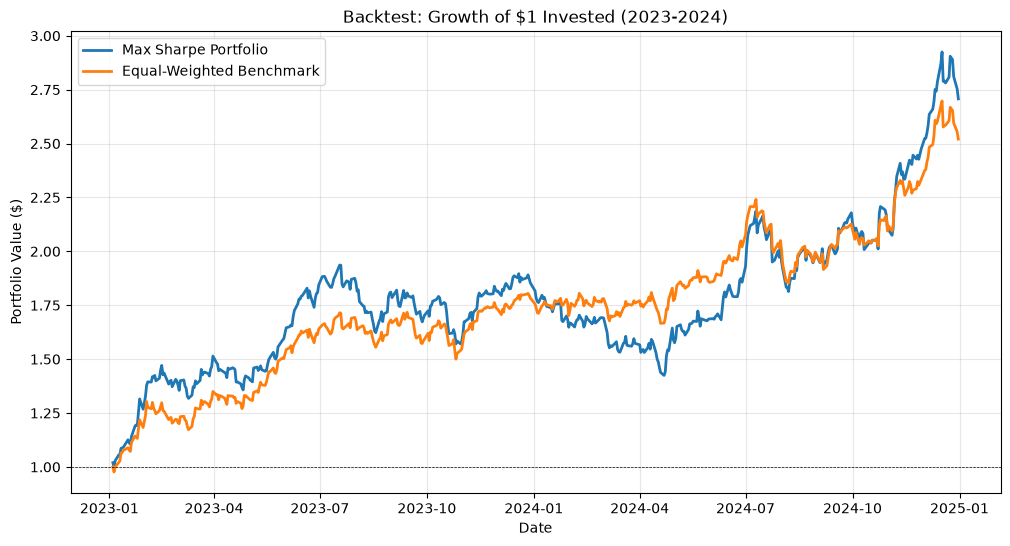

Max Sharpe Portfolio final value: $2.71
Equal-Weighted Benchmark final value: $2.52


In [5]:
# Calculate daily returns for the backtest period
backtest_returns = backtest_prices.pct_change().dropna()

# Portfolio 1: Max Sharpe weights (from optimization period)
portfolio_daily_returns = (backtest_returns * optimal_weights).sum(axis=1)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# Portfolio 2: Equal-weighted benchmark (20% each)
equal_weights_bt = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
equal_daily_returns = (backtest_returns * equal_weights_bt).sum(axis=1)
equal_cumulative = (1 + equal_daily_returns).cumprod()

# Plot both, starting from $1 invested
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative, label='Max Sharpe Portfolio', linewidth=2)
plt.plot(equal_cumulative.index, equal_cumulative, label='Equal-Weighted Benchmark', linewidth=2)
plt.axhline(1, color='black', linewidth=0.5, linestyle='--')
plt.title('Backtest: Growth of $1 Invested (2023-2024)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print final values
print(f"Max Sharpe Portfolio final value: ${portfolio_cumulative.iloc[-1]:.2f}")
print(f"Equal-Weighted Benchmark final value: ${equal_cumulative.iloc[-1]:.2f}")

## Performance Metrics: Max Sharpe vs. Equal-Weighted

Calculating standardized performance metrics — annualized return, volatility, Sharpe ratio,
and maximum drawdown — to rigorously compare the two portfolios beyond just final dollar value.

In [6]:
def calculate_metrics(daily_returns, name):
    annual_return = daily_returns.mean() * 252
    annual_volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = annual_return / annual_volatility

    # Max drawdown: largest peak-to-trough decline
    cumulative = (1 + daily_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    print(f"--- {name} ---")
    print(f"Annualized Return: {annual_return:.2%}")
    print(f"Annualized Volatility: {annual_volatility:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.3f}")
    print(f"Max Drawdown: {max_drawdown:.2%}\n")

calculate_metrics(portfolio_daily_returns, "Max Sharpe Portfolio")
calculate_metrics(equal_daily_returns, "Equal-Weighted Benchmark")

--- Max Sharpe Portfolio ---
Annualized Return: 54.32%
Annualized Volatility: 28.98%
Sharpe Ratio: 1.875
Max Drawdown: -26.42%

--- Equal-Weighted Benchmark ---
Annualized Return: 49.39%
Annualized Volatility: 23.87%
Sharpe Ratio: 2.069
Max Drawdown: -17.32%



## Findings: Backtest Results (2023-2024)

The Max Sharpe portfolio (weights calculated from 2019–2022 data) was tested on the
unseen 2023–2024 period, compared against a naive equal-weighted benchmark:

| Metric | Max Sharpe Portfolio | Equal-Weighted Benchmark |
|---|---|---|
| Final value ($1 invested) | $2.71 | $2.52 |
| Annualized Return | 54.32% | 49.39% |
| Annualized Volatility | 28.98% | 23.87% |
| Sharpe Ratio | 1.875 | 2.069 |
| Max Drawdown | -26.42% | -17.32% |

**Interpretation**: The Max Sharpe portfolio earned a higher absolute return, but this
came from taking on meaningfully more risk — both higher volatility and a notably deeper
maximum drawdown. On a risk-adjusted basis (Sharpe Ratio), the simple equal-weighted
benchmark actually performed *better* than the "optimized" portfolio out-of-sample.

This highlights a well-known limitation of mean-variance optimization: weights derived
from historical data (2019–2022, which includes TSLA's exceptional growth period) can
be overly concentrated in assets that performed well historically, without guarantee
that pattern persists. This is why practitioners often apply constraints (e.g., maximum
weight per asset) or regularly rebalance/re-optimize rather than using static,
history-derived weights indefinitely.